In [1]:
import pandas as pd
import glob

files = glob.glob(
    '/kaggle/input/datasets/sid321axn/beijing-multisite-airquality-data-set/*.csv'
)

print("CSV files found:", len(files))

df = pd.concat(
    [pd.read_csv(file) for file in files],
    ignore_index=True
)

print("Dataset shape:", df.shape)

CSV files found: 12
Dataset shape: (420768, 18)


In [2]:
print("Columns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nMissing values:")
print(df.isnull().sum())

Columns:
['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']

First 5 rows:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Guanyuan
1,2,2013,3,1,1,4.0,4.0,13.0,17.0,300.0,72.0,-1.1,1023.2,-18.2,0.0,N,4.7,Guanyuan
2,3,2013,3,1,2,3.0,3.0,10.0,19.0,300.0,69.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Guanyuan
3,4,2013,3,1,3,3.0,6.0,7.0,24.0,400.0,62.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Guanyuan
4,5,2013,3,1,4,3.0,6.0,5.0,14.0,400.0,71.0,-2.0,1025.2,-19.5,0.0,N,2.0,Guanyuan



Missing values:
No             0
year           0
month          0
day            0
hour           0
PM2.5       8739
PM10        6449
SO2         9021
NO2        12116
CO         20701
O3         13277
TEMP         398
PRES         393
DEWP         403
RAIN         390
wd          1822
WSPM         318
station        0
dtype: int64


In [3]:
# 复制数据，保留原始数据
clean_df = df.copy()

# 数值型栏目的缺失值：使用线性插值
numeric_columns = [
    'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
    'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM'
]

clean_df[numeric_columns] = (
    clean_df[numeric_columns]
    .interpolate(method='linear')
)

# 查看插值后还有多少缺失值
print("Missing values after interpolation:")
print(clean_df.isnull().sum())

Missing values after interpolation:
No            0
year          0
month         0
day           0
hour          0
PM2.5         0
PM10          0
SO2           0
NO2           0
CO            0
O3            0
TEMP          0
PRES          0
DEWP          0
RAIN          0
wd         1822
WSPM          0
station       0
dtype: int64


In [4]:
# 用该监测站最常见的风向填补缺失值
clean_df['wd'] = clean_df.groupby('station')['wd'].transform(
    lambda x: x.fillna(x.mode()[0])
)

print("Missing values in wd:", clean_df['wd'].isnull().sum())

Missing values in wd: 0


In [5]:
# 将文字类别转换为数值
model_df = pd.get_dummies(
    clean_df,
    columns=['wd', 'station'],
    drop_first=True
)

print("Original shape:", clean_df.shape)
print("Model-ready shape:", model_df.shape)

print("\nColumns:")
print(model_df.columns.tolist())

Original shape: (420768, 18)
Model-ready shape: (420768, 42)

Columns:
['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'wd_ENE', 'wd_ESE', 'wd_N', 'wd_NE', 'wd_NNE', 'wd_NNW', 'wd_NW', 'wd_S', 'wd_SE', 'wd_SSE', 'wd_SSW', 'wd_SW', 'wd_W', 'wd_WNW', 'wd_WSW', 'station_Changping', 'station_Dingling', 'station_Dongsi', 'station_Guanyuan', 'station_Gucheng', 'station_Huairou', 'station_Nongzhanguan', 'station_Shunyi', 'station_Tiantan', 'station_Wanliu', 'station_Wanshouxigong']


In [6]:
# 从原始数据重新开始清洗
clean_df = df.copy()

# 需要插值的输入特征
numeric_features = [
    'PM10', 'SO2', 'NO2', 'CO', 'O3',
    'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM'
]

# 按监测站分别进行线性插值
clean_df[numeric_features] = (
    clean_df.groupby('station')[numeric_features]
    .transform(lambda x: x.interpolate(method='linear'))
)

# 风向：按监测站使用最常见风向填补
clean_df['wd'] = clean_df.groupby('station')['wd'].transform(
    lambda x: x.fillna(x.mode()[0])
)

# PM2.5 是 Target，不能人工插值
# 删除 PM2.5 缺失的记录
clean_df = clean_df.dropna(subset=['PM2.5'])

print("Original rows:", len(df))
print("Rows after cleaning:", len(clean_df))

print("\nRemaining missing values:")
print(clean_df.isnull().sum())

Original rows: 420768
Rows after cleaning: 412029

Remaining missing values:
No          0
year        0
month       0
day         0
hour        0
PM2.5       0
PM10        0
SO2         0
NO2        22
CO          0
O3          0
TEMP        0
PRES        0
DEWP        0
RAIN        0
wd          0
WSPM        0
station     0
dtype: int64


In [7]:
# Fill remaining missing NO2 values using the median for each station
clean_df['NO2'] = clean_df.groupby('station')['NO2'].transform(
    lambda x: x.fillna(x.median())
)

# Check remaining missing values
print(clean_df.isnull().sum())

No         0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
dtype: int64


In [8]:
# 确认最终用于建模的数据
target = 'PM2.5'

features = [
    'PM10', 'SO2', 'NO2', 'CO', 'O3',
    'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM',
    'year', 'month', 'day', 'hour'
]

X = clean_df[features]
y = clean_df[target]

print("Features 数量:", len(features))
print("Features:", features)
print("\nX shape:", X.shape)
print("y shape:", y.shape)
print("\n是否还有缺失值:")
print("X 缺失值总数:", X.isnull().sum().sum())
print("y 缺失值总数:", y.isnull().sum())

Features 数量: 14
Features: ['PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'year', 'month', 'day', 'hour']

X shape: (412029, 14)
y shape: (412029,)

是否还有缺失值:
X 缺失值总数: 0
y 缺失值总数: 0


In [9]:
from sklearn.model_selection import train_test_split

# 划分训练集和测试集（80% 训练，20% 测试）
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("train size", X_train.shape, y_train.shape)
print("test size :", X_test.shape, y_test.shape)

train size (329623, 14) (329623,)
test size : (82406, 14) (82406,)


In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Faster model settings
model = RandomForestRegressor(
    n_estimators=50,        # reduced from 100 to 50
    max_depth=20,           # limit tree depth
    random_state=42,
    n_jobs=-1,
    verbose=1               # show progress
)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("===== Model Performance =====")
print(f"MAE  (Mean Absolute Error): {mae:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
print(f"R2   (Coefficient of Determination): {r2:.4f}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   46.5s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:   54.5s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.


===== Model Performance =====
MAE  (Mean Absolute Error): 10.48
RMSE (Root Mean Squared Error): 17.68
R2   (Coefficient of Determination): 0.9520


[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.4s
[Parallel(n_jobs=4)]: Done  50 out of  50 | elapsed:    0.5s finished


===== Feature Importance Ranking =====
Feature  Importance
   PM10    0.806216
     CO    0.098068
   DEWP    0.017923
    SO2    0.012637
   TEMP    0.009974
    day    0.008996
   PRES    0.008366
    NO2    0.008244
  month    0.007856
     O3    0.006683
   hour    0.005183
   year    0.005103
   WSPM    0.004307
   RAIN    0.000443


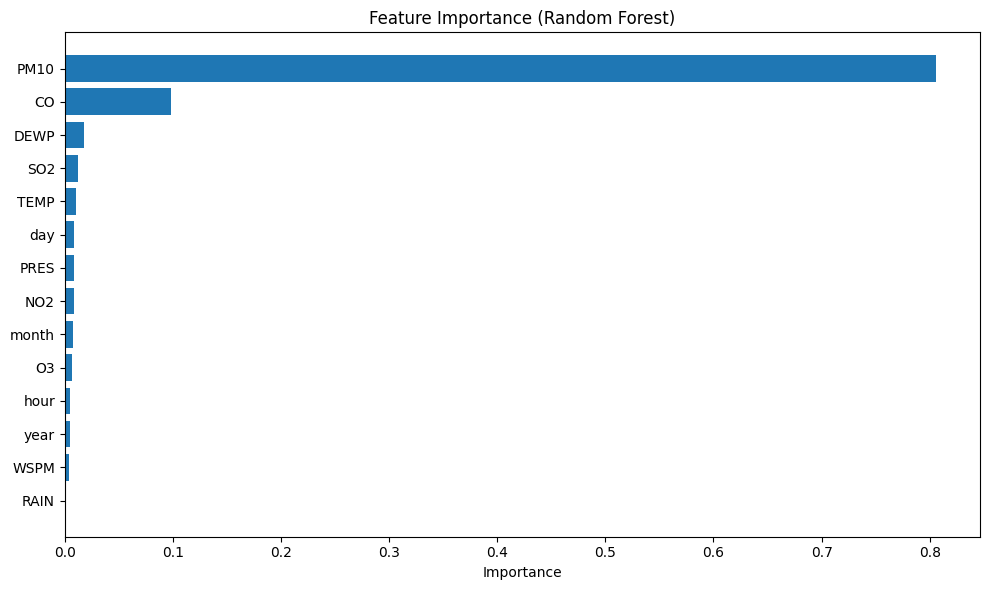

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("===== Feature Importance Ranking =====")
print(importance_df.to_string(index=False))

# Plot top features
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1])
plt.xlabel('Importance')
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()